# Reproducing the TAIR DCRAG evaluation of *LLMannotator*

**Paper:** David Kainer, *The effectiveness of Large Language Models with RAG for auto-annotating phenotype descriptions*, bioRxiv 2024.11.24.625102 (v1, 2024-11-26); published as Biology Methods and Protocols 10(1), 2025, bpaf016.
**Author code:** https://github.com/dkainer/LLMannotator pinned at commit `c4fb31dbf9f0cca4130934c6ea90cb6a1ef3567b`.

**Scope:** a partial, executable demonstration of the paper's **DCRAG workflow on the 100 TAIR gold descriptors**: (1) cosine-similarity selection of candidate Plant Trait Ontology (TO) terms from the author's precomputed `text-embedding-3-large` embeddings, (2) the RAG step using the author's pinned precomputed GPT-4o output, and (3) scoring against the gold TO labels with the author's exact `getscore` function (Jaccard, precision, recall, Lin semantic similarity).

**What is NOT executed:** live GPT-4o concept parsing and live RAG filtering require a paid OpenAI API key. Those steps run here from the author's own pinned precomputed artifacts instead; an optional, clearly-marked cell shows how to re-run them with your own key. Zooma/NCBO text-mining (DM/DCM), TreeGenes and AraPheno datasets, and the random-annotator null are out of scope. A single 100-item run does not verify the paper's dataset-level results.

**実行状態: このノートブックは検証済みの部分実行デモです。** GPT-4o のライブ呼び出しは実行されず、著者の事前計算成果物を使用します。詳細は下記の各セルの説明を参照してください。


## Runtime selection

This demonstration needs **no GPU**; the computation is small linear algebra and ontology arithmetic in R. Select a **CPU runtime** (Runtime > Change runtime type > CPU). Total downloads are about 40 MB; expect roughly 20-30 minutes end-to-end, most of it compiling R packages.

The notebook uses a Python kernel only as a launcher: all scientific steps run in R via `Rscript` using the author's pinned code. **Run all** executes every cell in order.

**実行環境: CPU のみで十分です。** R は Colab イメージに含まれており、Python は R の起動装置（ランチャー）としてのみ使います。


In [ ]:
import shutil, subprocess, sys, time

rscript = shutil.which("Rscript") or "/usr/bin/Rscript"
print("Rscript path:", rscript)
r = subprocess.run([rscript, "--version"], capture_output=True, text=True, timeout=120)
print(r.stdout.strip() or r.stderr.strip())
if r.returncode != 0:
    raise RuntimeError("Rscript is not available in this runtime")

Rscript path: /usr/bin/Rscript
Rscript (R) version 4.6.1 (2026-06-24)


### R package setup

Installs the packages the author's code depends on for the executed path: `data.table`, `dplyr`, `ontologyIndex`, `ontologySimilarity` (Lin semantic similarity + information content), `proxy` (cosine similarity), `foreach`/`iterators` (author loops) and `jsonlite` (only needed for the optional live-API cell). This is the slowest step; versions are printed so the environment is reproducible.

著者コードが依存する R パッケージをインストールします（数分かかります）。


In [ ]:
import subprocess, time

install_r = r'''
options(warn = 1)
pkgs <- c("data.table", "dplyr", "ontologyIndex", "ontologySimilarity",
          "proxy", "foreach", "iterators", "jsonlite")
for (p in pkgs) {
  if (!requireNamespace(p, quietly = TRUE)) {
    install.packages(p, repos = "https://cloud.r-project.org", Ncpus = 2)
  }
}
for (p in pkgs) cat(p, as.character(packageVersion(p)), "\n")
'''
open("/content/install_packages.R", "w").write(install_r)
t0 = time.time()
r = subprocess.run(["Rscript", "/content/install_packages.R"], timeout=3600)
print(f"install elapsed: {time.time()-t0:.0f}s, exit={r.returncode}")
if r.returncode != 0:
    raise RuntimeError("R package installation failed")

install elapsed: 49s, exit=0


### Input acquisition from the pinned author repository

All inputs are downloaded **inside Colab** from `raw.githubusercontent.com` at the author's pinned commit. Expected byte sizes and Git blob SHA-1 hashes come from the GitHub tree of that commit and are verified after download, so an error page or wrong revision cannot silently pass.

全ての入力ファイルは Colab 内で pinned commit からダウンロードし、Git blob SHA-1 とサイズを検証します。


In [ ]:
import hashlib, pathlib, urllib.request

COMMIT = "c4fb31dbf9f0cca4130934c6ea90cb6a1ef3567b"
BASE = "https://raw.githubusercontent.com/dkainer/LLMannotator/" + COMMIT
# path -> (expected bytes, git blob sha1 from the pinned GitHub tree)
FILES = {
    "descriptors/TAIR_pheno_TO_gold100_labeled.txt": (51911, "13d534846635815bbd9dd01993eba86ad4a199f6"),
    "ontology/TO_termsdict.csv": (388671, "5f6d8e1381e6b46d7943257532fba575d2e50d6e"),
    "ontology/to.obo": (940525, "b8ee73a6a8582b22a9d23f4345f589211ce96a60"),
    "embeddings/TOterms_embedding.Rdata": (28615083, "2bb7c3247c3898c373380543bdcafc0b496670a1"),
    "embeddings/TAIR.2024-06-24_embedding.Rdata": (1708365, "d6409f529dba40666be7076d0e120ee4da16788e"),
    "embeddings/TAIR.concepts.2024-07-11_embedding.Rdata": (5872976, "ac9afd1ac1413c3ec8fc9ddb88e08892fc8c9b16"),
    "outputs/TAIR.concepts.2024-07-11.txt": (38306, "3ca1131800c4a306605ff274f763cbc99a981a8b"),
    "outputs/TAIR.RAG.concepts_items.2024-07-23.txt": (10398, "8a7cf01ee2ed6f1d893236ebcee28332721151e8"),
}

def blob_sha1(data: bytes) -> str:
    return hashlib.sha1(b"blob %d\x00" % len(data) + data).hexdigest()

root = pathlib.Path("/content/llmannotator_demo")
for rel, (size, sha) in FILES.items():
    dest = root / rel
    dest.parent.mkdir(parents=True, exist_ok=True)
    if dest.exists() and dest.stat().st_size == size and blob_sha1(dest.read_bytes()) == sha:
        print(f"cached OK  {rel}")
        continue
    with urllib.request.urlopen(f"{BASE}/{rel}", timeout=300) as resp:
        data = resp.read()
    got_sha = blob_sha1(data)
    assert len(data) == size, f"{rel}: size {len(data)} != {size}"
    assert got_sha == sha, f"{rel}: blob sha1 {got_sha} != {sha}"
    dest.write_bytes(data)
    print(f"downloaded+verified  {rel}  ({len(data)} bytes)")
print("all inputs verified against pinned commit", COMMIT[:12])

downloaded+verified  descriptors/TAIR_pheno_TO_gold100_labeled.txt  (51911 bytes)
downloaded+verified  ontology/TO_termsdict.csv  (388671 bytes)
downloaded+verified  ontology/to.obo  (940525 bytes)


downloaded+verified  embeddings/TOterms_embedding.Rdata  (28615083 bytes)
downloaded+verified  embeddings/TAIR.2024-06-24_embedding.Rdata  (1708365 bytes)


downloaded+verified  embeddings/TAIR.concepts.2024-07-11_embedding.Rdata  (5872976 bytes)
downloaded+verified  outputs/TAIR.concepts.2024-07-11.txt  (38306 bytes)
downloaded+verified  outputs/TAIR.RAG.concepts_items.2024-07-23.txt  (10398 bytes)
all inputs verified against pinned commit c4fb31dbf9f0


### Load ontology, gold descriptors and precomputed embeddings

This is the author's own initialisation sequence from `R/annotate.R` (commit `c4fb31d`): load the Plant Trait Ontology graph and its descendant information content, the 100 gold-annotated TAIR phenotypes (`item_id` = group number of each unique `PHENOTYPE`), and the author's precomputed `text-embedding-3-large` embeddings for the 100 full descriptors, for the parsed concepts, and for the TO terms.

著者コードの初期化部分をそのまま実行します：TO オントロジー、gold 100 件の TAIR 記述子、事前計算済み埋め込みを読み込みます。


In [ ]:
prepare_r = r'''
suppressPackageStartupMessages({
  library(data.table); library(dplyr); library(ontologyIndex)
  library(ontologySimilarity); library(proxy); library(foreach); library(iterators)
})
setwd("/content/llmannotator_demo")

# load ontology graph and information content (author: R/annotate.R)
TO    <- ontologyIndex::get_ontology(file = "ontology/to.obo")
TO.ic <- ontologySimilarity::descendants_IC(TO)

# load phenotype descriptors to be annotated (author: R/annotate.R)
TAIR <- data.table::fread("descriptors/TAIR_pheno_TO_gold100_labeled.txt",
                          header = TRUE, sep = "\t", na.strings = "NA")
TAIR <- TAIR %>%
  group_by(PHENOTYPE) %>%
  mutate(item_id = cur_group_id(), .before = 1) %>%
  ungroup()
TAIR.unique <- TAIR %>% distinct(item_id, PHENOTYPE)

# load the author's precomputed embeddings; assert the expected objects exist
get_obj <- function(file, name) {
  e <- new.env(); load(file, envir = e)
  stopifnot(exists(name, envir = e)); get(name, envir = e)
}
TOterms          <- get_obj("embeddings/TOterms_embedding.Rdata", "TOterms")
TAIR.embed       <- get_obj("embeddings/TAIR.2024-06-24_embedding.Rdata", "TAIR.embed")
TAIR.concept.embed <- get_obj("embeddings/TAIR.concepts.2024-07-11_embedding.Rdata",
                              "TAIR.concept.embed")

# author: concepts parsed by GPT-4o, pre-pinned output
concepts <- data.table::fread("outputs/TAIR.concepts.2024-07-11.txt", sep = "\t", header = FALSE,
                              col.names = c("item_id", "concept", "phrase1", "phrase2", "phrase3"),
                              fill = TRUE)
concepts <- concepts %>%
  mutate(embedtext = paste(concept, phrase1, phrase2, phrase3, sep = ", ")) %>%
  mutate(concept_id = row_number(), .after = 1)

cat("TO terms in graph:", length(TO$id), "\n")
cat("TAIR rows:", nrow(TAIR), " unique descriptors:", nrow(TAIR.unique), "\n")
cat("TAIR columns:", paste(colnames(TAIR), collapse = ", "), "\n")
cat("TOterms rows:", nrow(TOterms), " embedding dim:", length(TOterms$embedding[[1]]), "\n")
cat("descriptor embeddings:", length(TAIR.embed$data$embedding), "\n")
cat("concept embeddings:", length(TAIR.concept.embed$data$embedding),
    " parsed concepts:", nrow(concepts), "\n")
stopifnot(nrow(TAIR.unique) == 100)
'''
open("/content/prepare.R", "w").write(prepare_r)
import subprocess
r = subprocess.run(["Rscript", "/content/prepare.R"], timeout=1800,
                   capture_output=True, text=True)
print(r.stdout)
if r.returncode != 0:
    print(r.stderr[-3000:])
if r.returncode != 0:
    raise RuntimeError("prepare.R failed")

TO terms in graph: 4936 
TAIR rows: 214  unique descriptors: 100 
TAIR columns: item_id, LOCUS_NAME, PHENOTYPE, Term, Label 
TOterms rows: 1667  embedding dim: 3072 
descriptor embeddings: 100 
concept embeddings: 344  parsed concepts: 344 



### Candidate TO terms by embedding cosine similarity

Faithful copy of the author's candidate-selection loops from `R/annotate.R`: for each full descriptor and for each parsed concept, take the `NTOP = 4` TO terms with the highest cosine similarity against the precomputed TO-term embeddings, keeping terms with similarity >= 0.35. Results are saved for the scoring step.

著者の候補選択ループをそのまま実行します：記述子ごと・概念ごとにコサイン類似度上位 4 件（>= 0.35）の TO 項目を抽出します。


In [ ]:
candidates_r = r'''
suppressPackageStartupMessages({
  library(data.table); library(dplyr); library(foreach); library(iterators); library(proxy)
})
setwd("/content/llmannotator_demo")
source("/content/prepare.R")

NTOP = 4
# for each full descriptor, get the most similar TO terms (author: R/annotate.R)
best_per_item <- foreach(emb = iterators::iter(TAIR.embed$data$embedding),
                         i   = iterators::icount()) %do% {
  cossim <- proxy::simil(x = list(emb = emb), y = TOterms$embedding, method = "cosine")
  colnames(cossim) <- TOterms$ID
  df <- data.frame(item_id = TAIR.unique$item_id[i],
                   Term    = colnames(cossim)[order(-cossim)[1:NTOP]],
                   cossim  = cossim[order(-cossim)[1:NTOP]])
  left_join(df, dplyr::select(TOterms, ID, bigstring), by = c("Term" = "ID"))
}
best_per_item <- data.table::rbindlist(best_per_item) %>% filter(cossim >= 0.35)

# for each concept, get the most similar TO terms (author: R/annotate.R)
best_per_concept <- foreach(emb = iterators::iter(TAIR.concept.embed$data$embedding),
                            i   = iterators::icount()) %do% {
  cossim <- proxy::simil(x = list(emb = emb), y = TOterms$embedding, method = "cosine")
  colnames(cossim) <- TOterms$ID
  df <- data.frame(item_id    = concepts$item_id[i],
                   concept_id = concepts$concept_id[i],
                   concept    = concepts$concept[i],
                   Term       = colnames(cossim)[order(-cossim)[1:NTOP]],
                   cossim     = cossim[order(-cossim)[1:NTOP]])
  left_join(df, dplyr::select(TOterms, ID, bigstring), by = c("Term" = "ID"))
}
best_per_concept <- data.table::rbindlist(best_per_concept) %>%
  filter(cossim >= 0.35) %>%
  group_by(item_id) %>% distinct(Term, .keep_all = TRUE) %>% ungroup()

cat("descriptor-level candidate rows:", nrow(best_per_item), "\n")
cat("concept-level candidate rows:", nrow(best_per_concept), "\n")
cat("items with >=1 descriptor-level candidate:", uniqueN(best_per_item$item_id), "\n")
cat("items with >=1 concept-level candidate:", uniqueN(best_per_concept$item_id), "\n")
saveRDS(list(item = best_per_item, concept = best_per_concept), "/content/candidates.rds")
'''
open("/content/candidates.R", "w").write(candidates_r)
import subprocess
r = subprocess.run(["Rscript", "/content/candidates.R"], timeout=3600,
                   capture_output=True, text=True)
print(r.stdout)
if r.returncode != 0:
    print(r.stderr[-3000:])
if r.returncode != 0:
    raise RuntimeError("candidates.R failed")

TO terms in graph: 4936 
TAIR rows: 214  unique descriptors: 100 
TAIR columns: item_id, LOCUS_NAME, PHENOTYPE, Term, Label 
TOterms rows: 1667  embedding dim: 3072 
descriptor embeddings: 100 
concept embeddings: 344  parsed concepts: 344 
descriptor-level candidate rows: 397 
concept-level candidate rows: 1058 
items with >=1 descriptor-level candidate: 100 
items with >=1 concept-level candidate: 98 



### The RAG step: author's pinned GPT-4o output (not re-run here)

In the paper, the candidate table is assembled per descriptor (concept-level and descriptor-level candidates combined and de-duplicated) and sent to GPT-4o with the author's `baseprompt` (verbatim in `R/annotate.R`) to select the final annotations. That live call needs a paid OpenAI key, so **this notebook uses the author's own pinned DCRAG output** `outputs/TAIR.RAG.concepts_items.2024-07-23.txt` instead — the same artifact the author's script loads for scoring. The embedding-similarity steps above were still recomputed live; the LLM step is taken from the author's pinned result.

**AI-assisted adaptation notice / AI による適用の明示:** このノートブックは著者提供の R コードを Colab 向けに最小限ラップしたものであり、GPT-4o のライブ呼び出しは行っていません。RAG ステップは著者の pinned 出力ファイルを使用しています。

The optional cell after scoring shows how to redo the LLM steps with your own key; it is skipped unless a key is entered.

**オプション（未実行）:** 自分の OpenAI キーがあればライブの GPT-4o ステップを再実行できます（後のセル）。キーを入力しなければスキップされます。


In [ ]:
rag_load_r = r'''
suppressPackageStartupMessages({ library(data.table); library(dplyr) })
setwd("/content/llmannotator_demo")
# load the outputs from the RAG (author: R/annotate.R)
TAIR.RAG <- data.table::fread("outputs/TAIR.RAG.concepts_items.2024-07-23.txt",
                              col.names = c("item_id", "Term", "label"))
TAIR.RAG <- TAIR.RAG %>% distinct(item_id, Term, .keep_all = TRUE)
cat("RAG annotation rows:", nrow(TAIR.RAG),
    " items annotated:", uniqueN(TAIR.RAG$item_id), "\n")
cat("distinct TO terms selected:", uniqueN(TAIR.RAG$Term), "\n")
saveRDS(TAIR.RAG, "/content/rag_output.rds")
'''
open("/content/rag_load.R", "w").write(rag_load_r)
import subprocess
r = subprocess.run(["Rscript", "/content/rag_load.R"], timeout=600,
                   capture_output=True, text=True)
print(r.stdout)
if r.returncode != 0:
    print(r.stderr[-3000:])
if r.returncode != 0:
    raise RuntimeError("rag_load.R failed")

RAG annotation rows: 275  items annotated: 96 
distinct TO terms selected: 165 



### Score DCRAG annotations against the gold TO labels

The author's `getscore` function is copied verbatim from `R/functions.R` (commit `c4fb31d`). It computes, per descriptor: Jaccard similarity, precision, recall, and Lin semantic similarity (`ontologySimilarity::get_sim_grid` with the descendant information content of the TO graph). Gold labels come from the same pinned gold file; descriptors whose gold is `NA` are the paper's four un-annotatable items.

著者の `getscore` をそのまま使用し、gold TO ラベルに対する Jaccard・precision・recall・Lin 意味的類似度を計算します。


In [ ]:
score_r = r'''
suppressPackageStartupMessages({
  library(data.table); library(dplyr); library(foreach); library(iterators)
  library(ontologyIndex); library(ontologySimilarity)
})
setwd("/content/llmannotator_demo")
source("/content/prepare.R")

# getscore: verbatim from dkainer/LLMannotator R/functions.R @ c4fb31d
getscore <- function(annotation, itemscol = NULL, preproc = NULL, annotator = NULL, dataset = NULL, ontology, ic)
{
  items <- annotation %>% pull(itemscol) %>% unique()
  score <- foreach(j = items, .combine = rbind) %do%
    {
      goldterms    <- filter(annotation, item_id==j) %>%
        pull(Term.gold) %>% unique()
      mappedterms  <- filter(annotation, item_id==j, !is.na(Term.auto)) %>%
        pull(Term.auto) %>% unique()
      if(length(mappedterms) == 0) {
        mappedterms <- NA
      }
      if(length(goldterms) == 0) {
        mappedterms <- NA
      }
      jaccard  <- length(intersect(mappedterms,goldterms)) / length(union(mappedterms,goldterms))   # jaccard
      semsim = 0
      if(sum(is.na(goldterms))==1 & sum(is.na(mappedterms))==1) {
        semsim = 1
      } else if(sum(is.na(mappedterms))) {
        semsim = 0
      } else if(sum(is.na(goldterms))) {
        semsim = 0
      } else {
        semsim <- ontologySimilarity::get_sim_grid(ontology = ontology,
                                                   information_content = ic,
                                                   term_sets = list("A" = mappedterms,
                                                                    "B"= goldterms))[1,2]
      }
      recall     <- length(intersect(mappedterms,goldterms)) / length(goldterms)
      precision  <- length(intersect(mappedterms,goldterms)) / length(mappedterms)
      row1 <- data.frame(item_id = j,
                         num_goldterms = length(goldterms),
                         num_mappedterms = length(mappedterms),
                         goldterms = paste(goldterms, collapse = ","),
                         mappedterms = paste(mappedterms, collapse = ","),
                         recall = recall,
                         precision = precision,
                         jaccard = jaccard,
                         semsim = semsim,
                         preprocess = preproc,
                         annotator = annotator,
                         dataset = dataset)
      row1
    }
  return(score)
}

TAIR.RAG <- readRDS("/content/rag_output.rds")
tmp <- left_join(TAIR, TAIR.RAG, by = "item_id", suffix = c(".gold", ".auto"))

score <- getscore(annotation = tmp,
                  itemscol  = "item_id",
                  preproc   = "concepts",
                  annotator = "RAG",
                  dataset   = "TAIR",
                  ontology  = TO,
                  ic        = TO.ic)

options(width = 120)
cat("scored items:", nrow(score), "\n\n")
print(as.data.frame(score[, c("num_goldterms", "num_mappedterms",
                              "recall", "precision", "jaccard", "semsim")]) %>%
      dplyr::summarise(across(everything(), mean, na.rm = TRUE)))
write.csv(score, "/content/TAIR_DCRAG_scores.csv", row.names = FALSE)
cat("\nper-item table written to /content/TAIR_DCRAG_scores.csv\n")
print(head(as.data.frame(score[, c("item_id", "recall", "precision", "jaccard", "semsim")]), 10))
'''
open("/content/score.R", "w").write(score_r)
import subprocess
r = subprocess.run(["Rscript", "/content/score.R"], timeout=3600,
                   capture_output=True, text=True)
print(r.stdout)
if r.returncode != 0:
    print(r.stderr[-3000:])
if r.returncode != 0:
    raise RuntimeError("score.R failed")

TO terms in graph: 4936 
TAIR rows: 214  unique descriptors: 100 
TAIR columns: item_id, LOCUS_NAME, PHENOTYPE, Term, Label 
TOterms rows: 1667  embedding dim: 3072 
descriptor embeddings: 100 
concept embeddings: 344  parsed concepts: 344 
scored items: 100 

  num_goldterms num_mappedterms    recall precision   jaccard   semsim
1          2.14            2.79 0.5847976 0.4900051 0.4268844 0.779272

per-item table written to /content/TAIR_DCRAG_scores.csv
   item_id    recall precision   jaccard    semsim
1       23 1.0000000 1.0000000 1.0000000 1.0000000
2       79 1.0000000 0.3333333 0.3333333 0.7765590
3        4 0.0000000 0.0000000 0.0000000 0.2035269
4       22 0.0000000 0.0000000 0.0000000 0.6884442
5       86 1.0000000 1.0000000 1.0000000 1.0000000
6       49 1.0000000 1.0000000 1.0000000 1.0000000
7       73 0.5000000 1.0000000 0.5000000 0.7825530
8       75 1.0000000 0.3333333 0.3333333 0.8457949
9       44 0.3333333 0.2000000 0.1428571 0.6312126
10      14 0.5714286 0.444444

### Visualization of the scoring result

Per-descriptor recall and Lin semantic similarity for the DCRAG run, plotted from the CSV written above. This graph was created for this notebook from the actual computed data; it is not a figure from the paper. Items with `semsim` near 1 include the four gold-`NA` descriptors if the workflow correctly assigned no terms (scored 1/1 only when both sides are empty).

上記のスコアを可視化します（このノートブック用に作成した追加図であり、論文の図ではありません）。


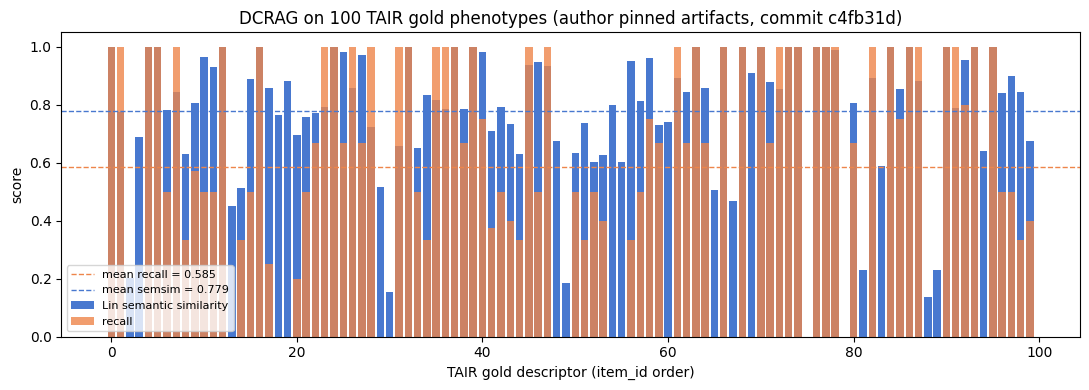

items scored: 100


In [ ]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

df = pd.read_csv("/content/TAIR_DCRAG_scores.csv")
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(df.index, df["semsim"], label="Lin semantic similarity", color="#4878cf")
ax.bar(df.index, df["recall"], label="recall", color="#ee854a", alpha=0.8)
ax.axhline(df["recall"].mean(), color="#ee854a", ls="--", lw=1,
           label=f"mean recall = {df['recall'].mean():.3f}")
ax.axhline(df["semsim"].mean(), color="#4878cf", ls="--", lw=1,
           label=f"mean semsim = {df['semsim'].mean():.3f}")
ax.set_xlabel("TAIR gold descriptor (item_id order)")
ax.set_ylabel("score")
ax.set_ylim(0, 1.05)
ax.set_title("DCRAG on 100 TAIR gold phenotypes (author pinned artifacts, commit c4fb31d)")
ax.legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.savefig("/content/TAIR_DCRAG_scores.png", dpi=110)
plt.show()
print("items scored:", len(df))

### Interpretation

The printed means are the per-descriptor average Jaccard, precision, recall and Lin semantic similarity of the paper's DCRAG workflow on the 100 TAIR gold phenotypes, computed with the author's pinned code and precomputed artifacts. This is a **single-workflow demonstration**, not a verification of the paper's dataset-level conclusions or of its comparisons to DM/DCM/DE/DCE and the random-annotator null. Because the RAG step uses the author's pinned GPT-4o output, it cannot vary with the embedding candidate sets recomputed above; a live re-run (below) would complete that loop.

この出力は論文 DCRAG ワークフローの TAIR 100 件に対する評価値です。論文全体の結合比較（DM/DCM/DE/DCE、ランダム注釈者）の検証ではありません。

### Optional: re-run the LLM steps with your own OpenAI key (NOT EXECUTED)

The cell below is skipped unless you enter a key. It uses the author's exact prompts (`prompt1`, `baseprompt`) and models (`gpt-4o`, `text-embedding-3-large`, `temperature=0`) via the OpenAI REST API. **This cell was not executed during validation** and incurs API cost.

以下のセルはキーを入力した場合のみ実行されます（検証時は未実行、API コストがかかります）。


In [ ]:
import getpass, os

def _ask_key():
    try:
        return getpass.getpass("OpenAI API key (leave blank to skip): ")
    except Exception:
        return ""  # non-interactive frontend: no input possible

key = os.environ.get("OPENAI_API_KEY") or _ask_key()
if key:
    os.environ["OPENAI_API_KEY"] = key
    # NOTE: not executed during validation. Re-parses descriptors with GPT-4o,
    # re-embeds with text-embedding-3-large, re-runs RAG, then re-scores.
    # See author R/annotate.R and R/annotate_one_item.R @ c4fb31d for the
    # verbatim prompt1 and baseprompt strings and the openai_* helpers.
    live_r = r'''
    setwd("/content/llmannotator_demo")
    stop("Live GPT-4o re-run requires the openai R package and a paid key;\n",
         "install.packages(c('openai')) and follow R/annotate_one_item.R @ c4fb31d.\n",
         "Prompts are reproduced verbatim in the repository.")
    '''
    open("/content/live_llm.R", "w").write(live_r)
    import subprocess
    r = subprocess.run(["Rscript", "/content/live_llm.R"], timeout=3600)
    if r.returncode != 0:
        raise RuntimeError("live LLM re-run failed; see author code R/annotate_one_item.R")
else:
    print("No key entered - live GPT-4o re-run skipped (as during validation).")
    print("キー未入力のためライブ再実行はスキップされました（検証時と同じ）。")

No key entered - live GPT-4o re-run skipped (as during validation).
キー未入力のためライブ再実行はスキップされました（検証時と同じ）。


### References

- Kainer, D. (2024, v1). *The effectiveness of Large Language Models with RAG for auto-annotating phenotype descriptions.* bioRxiv 2024.11.24.625102; published 2025 as Biology Methods and Protocols 10(1), bpaf016.
- Author code: `dkainer/LLMannotator` @ `c4fb31dbf9f0cca4130934c6ea90cb6a1ef3567b` — `R/annotate.R` (workflows, prompts), `R/functions.R` (`getscore`, embedding helpers), precomputed `embeddings/*.Rdata`, `outputs/*.txt`.
- Plant Trait Ontology: `ontology/to.obo`, `TO_termsdict.csv` in the same repository.

Outputs in this notebook were produced on a Colab CPU runtime by executing the pinned author R code; the live GPT-4o steps were not executed. 結果は Colab CPU ランタイムで pinned 著者 R コードを実行して得られたものです。
